# <div align="center"><u>Project 11 - Version 1 - Everything</u>
    
- The following analysis focuses on the binary classification of healthy individuals versus cancer patients. The specific pathology addressed is Pancreatic Ductal Adenocarcinoma (PDAC), which accounts for approximately 90% of all pancreatic cancer cases. Due to the asymptomatic nature of its early stages, early detection remains a significant hurdle. Consequently, it is a high-priority challenge for researchers to develop machine learning algorithms and diagnostic solutions capable of identifying the disease in its infancy.
    
- The dataset utilized in this study consists of synthetic data, generated to reflect real-world clinical distributions. Each record adheres to established medical parameters and biological constraints observed in Pancreatic Ductal Adenocarcinoma (PDAC) patients and healthy controls:
    
    - Well-established bioindicators:
        - CA19-9, 12.5(±8.0) for healthy, 450(±210) for cancer, primary pancreatic rumor marker.
        - CEA, 1.8(±1.2) for healthy, 8.5(±5.5) for cancer, general marker for GI tract cancer.
        - Bilirubin(Total), 0.6(±0.3) for healthy, 2.4(±1.8) for cancer, elevated if tumor blocks bile ducts.
        - Alkaline Phosphatase, 70.0(±20.0) for healthy, 210.0(±95.0) for cancer, indicates liver/bile duct stress.
        - ALT (Alanine Aminotransferase), 25.0(±10.0) for healthy, 55.0(±30.0) for cancer, marker for secondary liver impact.
        - Albumin, 4.4(±0.4) for healthy, 3.2(±0.7) for cancer, drops due to inflammation/malnutrition.
        - CRP (C-Reactive Protein), 1.5(±1.0) for healthy, 15.0(±12.0) for cancer, general systemic inflammation marker.
        - Glucose (Fasting), 90.0(±10.0) for healthy, 135.0(±40.0) for cancer, New-onset diabetes is a PDAC sympton.
        - Hemoglobin, 14.5(±1.5) for healthy, 11.5(±2.0) for cancer, cancer often causes mild anemia.
        - Platelet Count, 250(±60) for healthy, 380(±110) for cancer, paraneoplastic thrombocytosis (high platelets).
        
       

##############################################################################################################################

###  Import libraries

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import random
import time

import random
import time

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, log_loss, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score

### Suppress warnings

In [26]:
# Suppress all warnings
import warnings

warnings.filterwarnings("ignore")

### Start time

In [27]:
# Start time
start_time = time.time()

### Generate some data

In [28]:
# Set seed for reproducibility
np.random.seed(42)

# Function that generates data based on real life spectrum values
def generate_data(n_samples, label):
    data = {
        # --- Cancer-Related Indicators (High Signal) ---
        'CA_19_9':       np.random.normal(12.5 if label == 0 else 450.0, 8.0 if label == 0 else 210.0, n_samples),
        'CEA':           np.random.normal(1.8  if label == 0 else 8.5,   1.2 if label == 0 else 5.5,   n_samples),
        'Bilirubin':     np.random.normal(0.6  if label == 0 else 2.4,   0.3 if label == 0 else 1.8,   n_samples),
        'Alkaline_Phos': np.random.normal(70.0 if label == 0 else 210.0, 20.0 if label == 0 else 95.0, n_samples),
        'ALT':           np.random.normal(25.0 if label == 0 else 55.0,  10.0 if label == 0 else 30.0, n_samples),
        'Albumin':       np.random.normal(4.4  if label == 0 else 3.2,   0.4 if label == 0 else 0.7,   n_samples),
        'CRP':           np.random.normal(1.5  if label == 0 else 15.0,  1.0 if label == 0 else 12.0,  n_samples),
        'Glucose':       np.random.normal(90.0 if label == 0 else 135.0, 10.0 if label == 0 else 40.0, n_samples),
        'Hemoglobin':    np.random.normal(14.5 if label == 0 else 11.5,  1.5 if label == 0 else 2.0,   n_samples),
        'Platelets':     np.random.normal(250  if label == 0 else 380,   60  if label == 0 else 110,   n_samples),
        'Target': [label] * n_samples
    }
    return pd.DataFrame(data)

# Set number of samples for each
n_samples = 100

# Generate 100 samples for each
healthy_df = generate_data(n_samples, 0) # 0 = Healthy
cancer_df = generate_data(n_samples, 1)  # 1 = Cancer (PDAC)

# Combine and shuffle
df = pd.concat([healthy_df, cancer_df]).sample(frac=1).reset_index(drop=True)

# Ensure no negative values (biological constraint)
df[df.columns[:-1]] = df[df.columns[:-1]].clip(lower=0.1)

df

,CA_19_9,CEA,Bilirubin,Alkaline_Phos,ALT,Albumin,CRP,Glucose,Hemoglobin,Platelets,Target
0,351.782748,11.771149,1.076046,167.888186,19.123508,2.106218,25.087440,139.928192,9.318067,358.560089,1
1,9.878703,0.305113,0.854881,106.629175,16.387158,4.533465,2.115936,77.232514,16.253943,209.080945,0
2,180.571633,8.155738,1.830465,56.711667,55.440646,2.250393,3.931078,142.784298,13.059321,401.420981,1
3,13.196377,1.815602,0.659718,87.446413,30.765570,4.494246,0.389424,82.728628,13.723583,222.861621,0
4,142.481275,1.748157,1.403541,181.265380,103.220367,2.827109,20.083189,92.287883,11.717119,431.446249,1
...,...,...,...,...,...,...,...,...,...,...,...
195,24.804293,0.821028,0.169241,79.959966,1.980788,5.070575,0.100000,84.375332,13.302554,209.136901,0
196,12.540908,1.869850,0.843859,67.709203,16.243817,4.222283,2.424027,90.283184,16.309763,215.729261,0
197,0.100000,2.132029,0.305547,113.063649,41.449677,4.731762,0.100000,96.218100,14.450310,223.228994,0
198,644.173073,0.100000,1.627070,304.244023,71.099583,2.814170,31.498517,154.567485,11.378678,343.279856,1


### Set parameters

In [29]:
# Set parameters
number_of_splits = 50
test_size = 0.25
neighbor_cases = [3, 5, 9, 11]  # The 4 cases you wanted

### Prepare data

In [30]:
# Prepare data
X = df.iloc[:, :-1].values  # Features
y = df['Target'].values     # Classes-Labels

# Create an empty dictionary to hold the results for each k
results = {}

### Function that applies Monte Carlo Cross Validation (MCCV)

In [31]:
# Function that applies Monte Carlo Cross Validation
def kNN_MCCV(X, y, n_neighbors, test_size, num_splits): # Removed default values from def for clarity with external variables
    
    train_scores = np.zeros(num_splits)
    test_scores = np.zeros(num_splits)
    train_losses = np.zeros(num_splits)
    test_losses = np.zeros(num_splits)

    test_precision_scores = np.zeros(num_splits)
    test_recall_scores = np.zeros(num_splits)
    test_f1_scores = np.zeros(num_splits)
    test_auc_roc_scores = np.zeros(num_splits)

    labels = np.unique(y)
    n_classes = len(labels)
    cm_total = np.zeros((n_classes, n_classes), dtype=np.float64)

    for i in range(num_splits):
        x_train, x_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, shuffle=True, stratify=y, random_state=i
        )

        scaler = StandardScaler()
        x_train_scaled = scaler.fit_transform(x_train)
        x_test_scaled = scaler.transform(x_test)

        model = KNeighborsClassifier(n_neighbors=n_neighbors)
        model.fit(x_train_scaled, y_train)

        y_train_pred = model.predict(x_train_scaled)
        y_test_pred = model.predict(x_test_scaled)

        # Calculate accuracy for train and test
        train_scores[i] = accuracy_score(y_train, y_train_pred)
        test_scores[i] = accuracy_score(y_test, y_test_pred)

        # Calculate and store precision, recall, f1_score and AUC-ROC metrics for the test set
        test_precision_scores[i] = precision_score(y_test, y_test_pred, average='binary', labels=labels, zero_division=0)
        test_recall_scores[i] = recall_score(y_test, y_test_pred, average='binary', labels=labels, zero_division=0)
        test_f1_scores[i] = f1_score(y_test, y_test_pred, average='binary', labels=labels, zero_division=0)
        
        # If predict_proba is available
        if hasattr(model, "predict_proba"):
            y_train_proba = model.predict_proba(x_train_scaled)
            y_test_proba = model.predict_proba(x_test_scaled)

            test_auc_roc_scores[i] = roc_auc_score(y_test, y_test_proba[:, 1])
                
        else:
            test_auc_roc_scores[i] = np.nan

        cm = confusion_matrix(y_test, y_test_pred, labels=labels)
        cm_total += cm

    cm_avg = cm_total / num_splits
    
    return (
        train_scores,
        test_scores,
        test_precision_scores, 
        test_recall_scores,     
        test_f1_scores,         
        test_auc_roc_scores,    
        cm_avg,
        labels,
    )

### Apply MCCV

In [32]:
# Automatically loop through each neighbor value
for k in neighbor_cases:
    print(f"Running MCCV for k = {k}")

    # Call your original function
    (
        train_scores,
        test_scores,
        test_precision,
        test_recall,
        test_f1,
        test_auc_roc,
        cm_avg,
        labels,
    ) = kNN_MCCV(X, y, n_neighbors=k, test_size=test_size, num_splits=number_of_splits)

    # Save the specific arrays you want inside the dictionary under the key 'k'
    results[k] = {
        "test_scores": test_scores,
        "precision": test_precision,
        "recall": test_recall,
        "f1": test_f1,
        "auc_roc": test_auc_roc,
    }

print("All iterations finished and data is saved successfully!")

Running MCCV for k = 3
Running MCCV for k = 5
Running MCCV for k = 9
Running MCCV for k = 11
All iterations finished and data is saved successfully!


### Plot the metrics

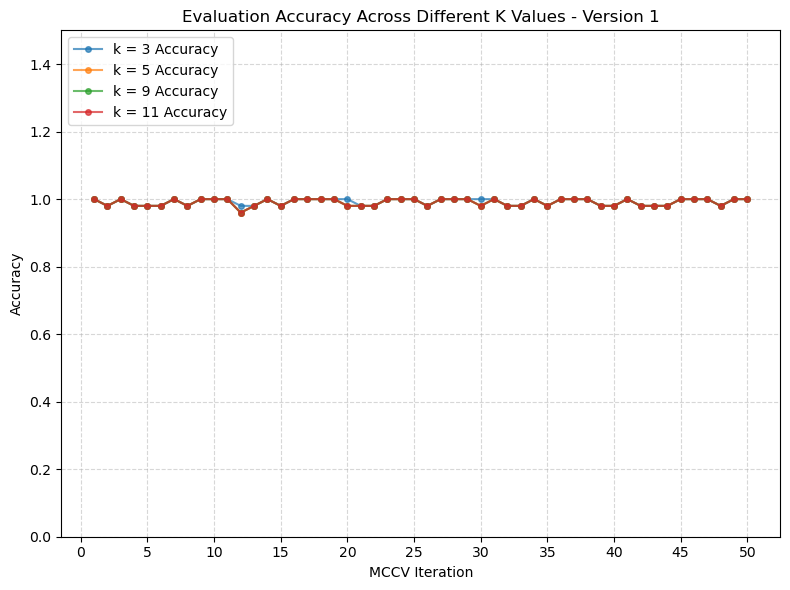

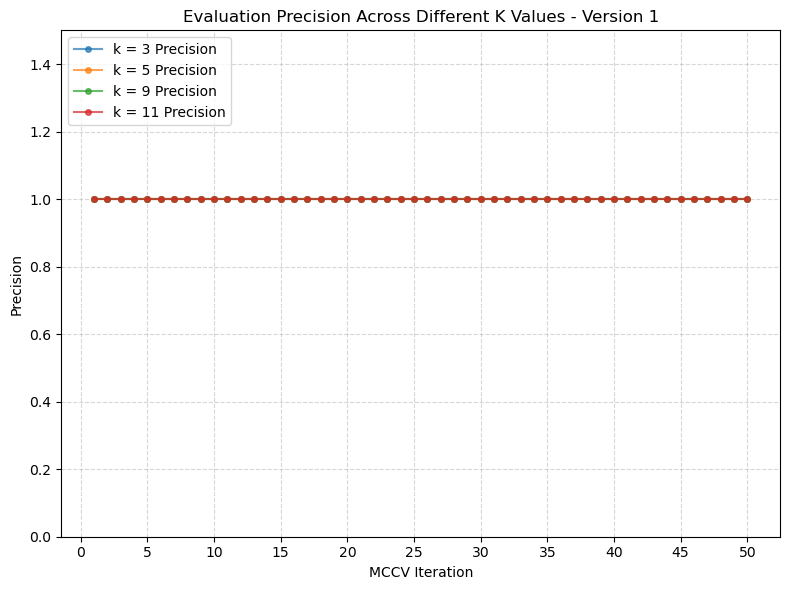

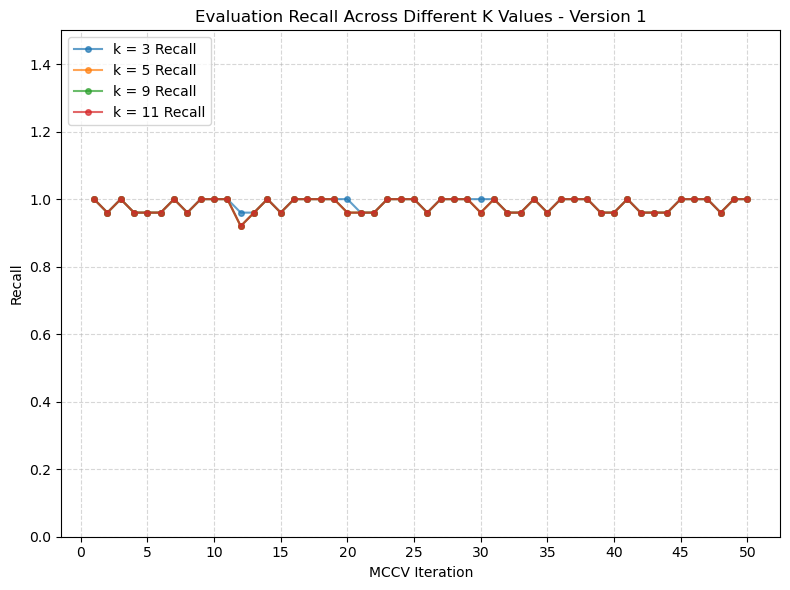

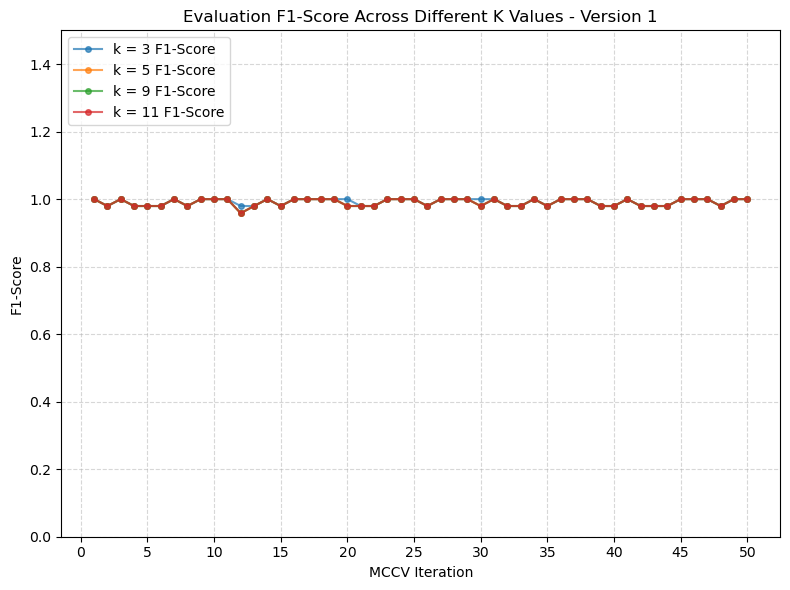

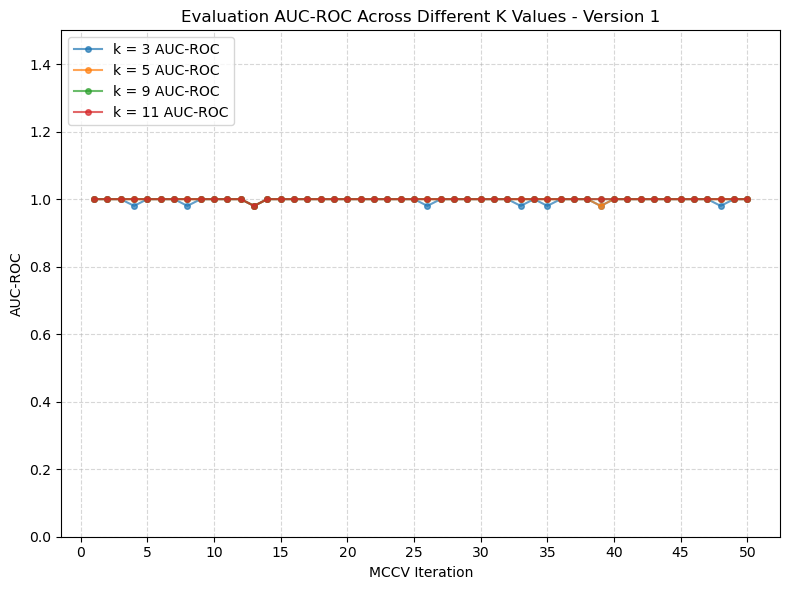

In [33]:
# 1. Define the metrics mapping (Dictionary Key -> Label Name on Graph)
metrics_to_plot = {
    "test_scores": "Accuracy",
    "precision": "Precision",
    "recall": "Recall",
    "f1": "F1-Score",
    "auc_roc": "AUC-ROC",
}

iterations = np.arange(1, number_of_splits + 1)

# 2. Iterate through each metric to create a separate plot
for metric_key, metric_name in metrics_to_plot.items():

    # Open a brand new figure window for the current metric
    plt.figure(figsize=(8, 6))

    # Plot all k-cases for this specific metric
    for k in neighbor_cases:
        plt.plot(
            iterations,
            results[k][metric_key],  # Dynamically pulls the array
            marker="o",
            markersize=4,
            linestyle="-",
            alpha=0.7,
            label=f"k = {k} {metric_name}",
        )

    # 3. Apply your required formatting rules to the plot
    plt.title(
        f"Evaluation {metric_name} Across Different K Values - Version 1", fontsize=12
    )
    plt.xlabel("MCCV Iteration", fontsize=10)
    plt.ylabel(f"{metric_name}", fontsize=10)
    plt.xticks(np.arange(0, number_of_splits + 1, 5))

    # Your custom y-axis constraint
    plt.ylim(0, 1.5)

    plt.grid(True, linestyle="--", alpha=0.5)

    # Your custom legend position constraint
    plt.legend(loc="upper left")

    plt.tight_layout()

    # Render the plot before moving to the next metric in the loop
    plt.show()

### Plot the average values of the metrics

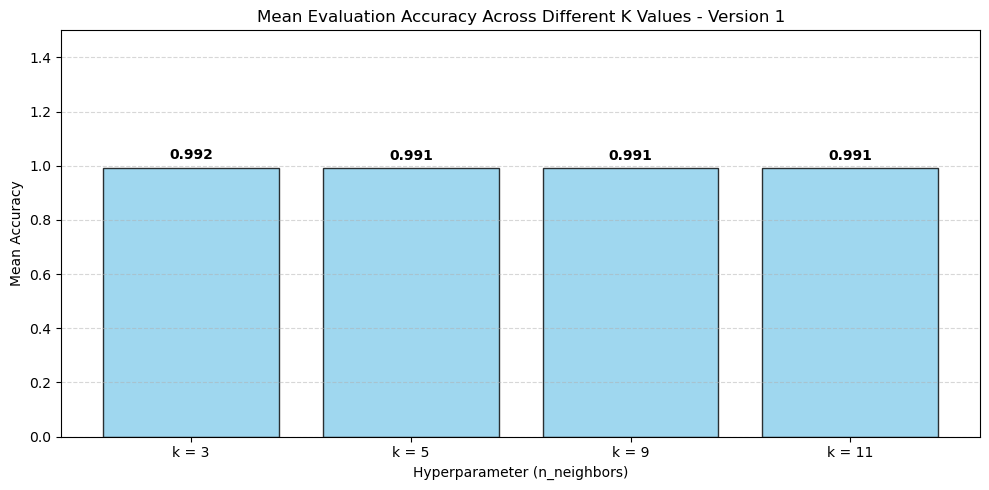

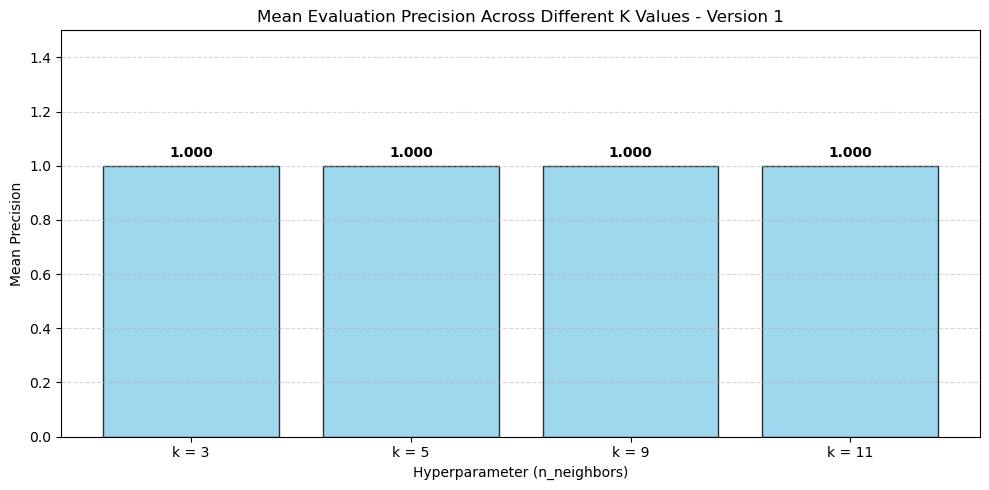

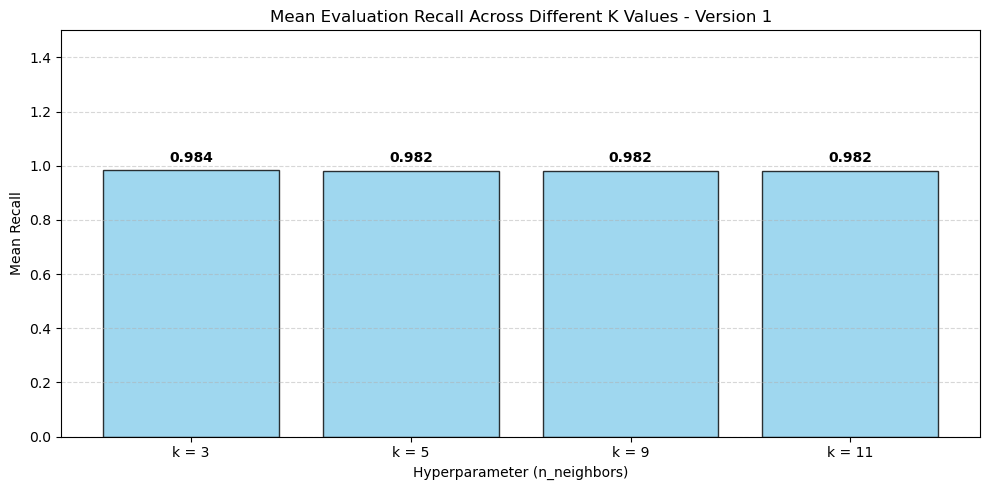

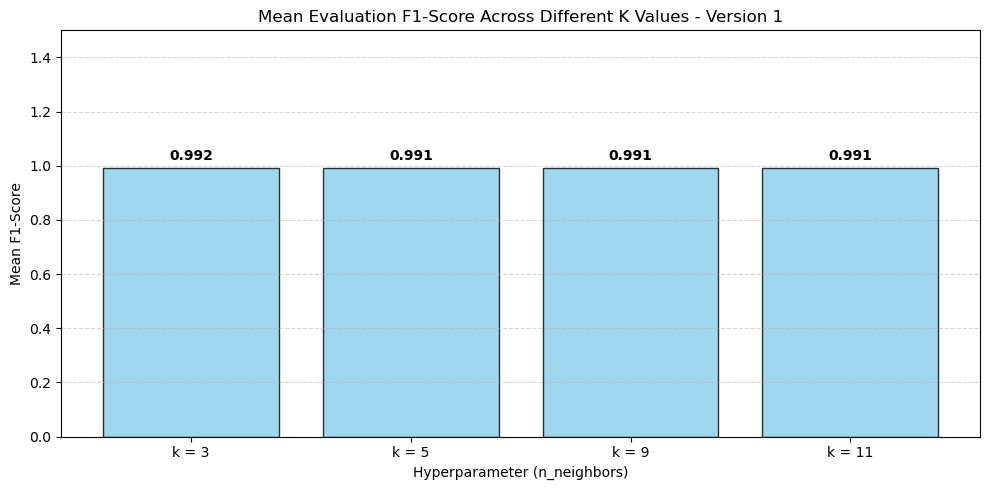

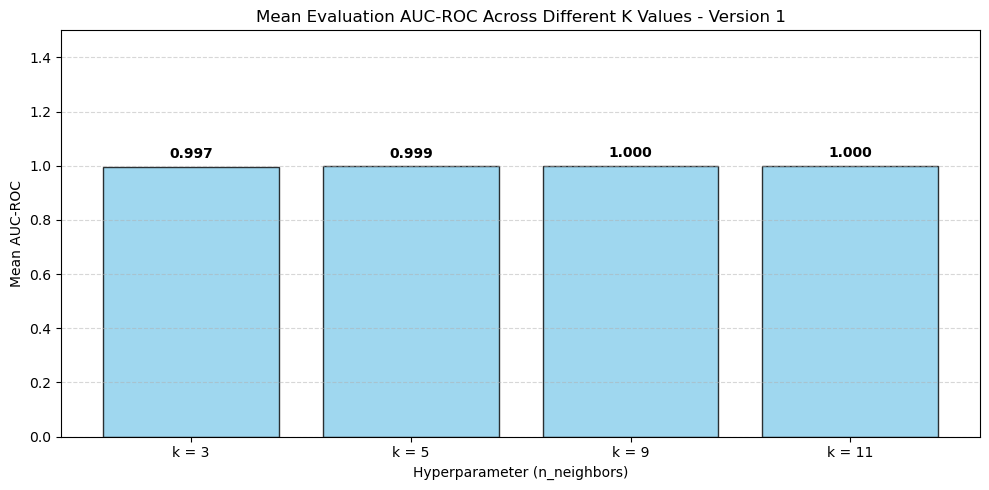

In [34]:
# Convert neighbor cases to strings so matplotlib treats them as distinct categories on the X-axis
x_labels = [f"k = {k}" for k in neighbor_cases]

# 2. Iterate through each metric to create a separate Bar Plot
for metric_key, metric_name in metrics_to_plot.items():

    # Calculate the mean value for each k case
    mean_values = []
    for k in neighbor_cases:
        mean_score = np.mean(results[k][metric_key])
        mean_values.append(mean_score)

    # Open a brand new figure window for the current bar chart
    plt.figure(figsize=(10, 5))

    # Create the bar plot
    # We can assign different colors or keep it uniform. alpha adjusts transparency.
    bars = plt.bar(
        x_labels, mean_values, color="skyblue", edgecolor="black", alpha=0.8
    )

    # Add value labels on top of each bar for easier reading
    for bar in bars:
        height = bar.get_height()
        # Checks if the height is a valid number (handles np.nan if AUC-ROC failed)
        if not np.isnan(height):
            plt.text(
                bar.get_x() + bar.get_width() / 2.0,
                height + 0.02,
                f"{height:.3f}",
                ha="center",
                va="bottom",
                fontsize=10,
                weight="bold",
            )

    # 3. Apply your formatting rules
    plt.title(f"Mean Evaluation {metric_name} Across Different K Values - Version 1", fontsize=12)
    plt.xlabel("Hyperparameter (n_neighbors)", fontsize=10)
    plt.ylabel(f"Mean {metric_name}", fontsize=10)

    # Your custom y-axis constraint
    plt.ylim(0, 1.5)

    plt.grid(axis="y", linestyle="--", alpha=0.5)

    plt.tight_layout()

    # Render the bar plot before moving to the next metric loop
    plt.show()

In [35]:
# End time
end_time = time.time()

### Elapsed time

In [36]:
# Elapsed time
elapsed_time = end_time - start_time

print(f"Elapsed time for kNN (Version 1): {elapsed_time:.2f} seconds")

Elapsed time for kNN (Version 1): 4.98 seconds
